In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Reloading expression data
filepath = "../data/GSE2034_series_matrix.txt"

expr_df = pd.read_csv(filepath, sep='\t', comment='!', index_col=0)
expr_df.columns = expr_df.columns.str.replace('"', '')

# Reloading clinical data
metadata = {}
with open(filepath, 'r') as f:
    for line in f:
        if line.startswith('!'):
            parts = line.strip().split('\t')
            metadata[parts[0]] = parts[1:]
        elif line.startswith('"ID_REF"'):
            break

clinical_df = pd.DataFrame({
    'sample_id': metadata['!Sample_geo_accession'],
    'relapse': metadata['!Sample_characteristics_ch1']
})
clinical_df['sample_id'] = clinical_df['sample_id'].str.replace('"', '') 
clinical_df['relapse'] = clinical_df['relapse'].str.extract(r'(\d)$')
clinical_df = clinical_df.dropna(subset=['relapse']) # clinical data has some NaN values we handled it using this line 
# This drops any rows where relapse is NaN before trying to convert to integer. 
# So now only rows with a valid 0 or 1 value survive, and the conversion works cleanly.

clinical_df['relapse'] = clinical_df['relapse'].astype(int)

print(f"Expression data: {expr_df.shape}")
print(f"Clinical data: {clinical_df.shape}")
print(f"Relapse counts:\n{clinical_df['relapse'].value_counts()}")
print("Data reloaded successfully")

Expression data: (22283, 286)
Clinical data: (0, 2)
Relapse counts:
Series([], Name: count, dtype: int64)
Data reloaded successfully


The clinical data is empty - meaning none of the rows matched our pattern. The metadata structure is slightly different in this file. Let's investigate it first.

In [4]:
# inspecting raw metadata to understand the structure
for key, values in metadata.items():
    if 'haracteristic' in key:
        print(f"Key: {key}")
        print(f"First 5 values: {values[:5]}")
        print()

Key: !Sample_characteristics_ch1
First 5 values: ['"bone relapses (1=yes, 0=no): 0"', '"bone relapses (1=yes, 0=no): 0"', '"bone relapses (1=yes, 0=no): 0"', '"bone relapses (1=yes, 0=no): 0"', '"bone relapses (1=yes, 0=no): 0"']



The values still have quotes around them. That's why the pattern didn't match. The quotes weren't stripped before extracting.

In [5]:
clinical_df = pd.DataFrame({
    'sample_id': metadata['!Sample_geo_accession'],
    'relapse': metadata['!Sample_characteristics_ch1']
})

# Strip quotes first, THEN extract
clinical_df['sample_id'] = clinical_df['sample_id'].str.replace('"', '')
clinical_df['relapse'] = clinical_df['relapse'].str.replace('"', '')
clinical_df['relapse'] = clinical_df['relapse'].str.extract(r'(\d)$')
clinical_df = clinical_df.dropna(subset=['relapse'])
clinical_df['relapse'] = clinical_df['relapse'].astype(int)

print(f"Clinical data: {clinical_df.shape}")
print(f"Relapse counts:\n{clinical_df['relapse'].value_counts()}")

Clinical data: (286, 2)
Relapse counts:
relapse
0    217
1     69
Name: count, dtype: int64


In [6]:
#differential expression analysis - running a t-test for every single gene comparing relapsed vs non-relapsed patients

# Splitting samples into two groups
relapse_samples = clinical_df[clinical_df['relapse'] == 1]['sample_id'].tolist()
no_relapse_samples = clinical_df[clinical_df['relapse'] == 0]['sample_id'].tolist()

# Getting expression values for each group
relapse_expr = expr_df[relapse_samples]
no_relapse_expr = expr_df[no_relapse_samples]

print(f"Relapsed group: {relapse_expr.shape[1]} samples")
print(f"No relapse group: {no_relapse_expr.shape[1]} samples")

Relapsed group: 69 samples
No relapse group: 217 samples


In [8]:
# Running t-test for every gene(all 22,283 genes)
results = []

for gene in expr_df.index:
    group1 = relapse_expr.loc[gene].values.astype(float)
    group2 = no_relapse_expr.loc[gene].values.astype(float)
    
    # t-test
    t_stat, p_value = stats.ttest_ind(group1, group2)
    
    # fold change (log2)
    mean1 = np.mean(group1)
    mean2 = np.mean(group2)
    log2fc = np.log2(mean1 / mean2)
    
    results.append({
        'gene': gene,
        'log2_fold_change': log2fc,
        'p_value': p_value,
        't_statistic': t_stat
    })

results_df = pd.DataFrame(results)
results_df = results_df.set_index('gene')

print(f"Analysis complete! {len(results_df)} genes tested")
print(results_df.head())

Analysis complete! 22283 genes tested
           log2_fold_change   p_value  t_statistic
gene                                              
1007_s_at          0.020521  0.750777     0.317923
1053_at           -0.170970  0.072620    -1.801908
117_at             0.089689  0.538740     0.615467
121_at             0.060575  0.267502     1.111014
1255_g_at          0.040779  0.691816     0.396796


what the columns mean:

log2_fold_change - how much higher/lower the gene is in relapsed vs non-relapsed (positive = higher in relapsed)

p_value - how statistically significant the difference is (lower = more significant)

t_statistic - the raw test statistic

In [10]:
# applying multiple testing correction and filter for significant genes

from statsmodels.stats.multitest import multipletests

# Applying Benjamini-Hochberg correction
_, p_adjusted, _, _ = multipletests(results_df['p_value'], method='fdr_bh')
results_df['p_adjusted'] = p_adjusted

# flag significant genes
results_df['significant'] = (
    (results_df['p_adjusted'] < 0.05) & 
    (results_df['log2_fold_change'].abs() > 0.5)
)

print(f"Total significant genes: {results_df['significant'].sum()}")
print(f"\nTop 10 most significant genes:")
results_df[results_df['significant']].sort_values('p_adjusted').head(10)

Total significant genes: 63

Top 10 most significant genes:


,log2_fold_change,p_value,t_statistic,p_adjusted,significant
gene,,,,,
209380_s_at,0.590319,3.992553e-08,5.645400,0.000445,True
203218_at,0.547832,3.363678e-08,5.678130,0.000445,True
202630_at,0.534049,1.558300e-06,4.907319,0.006664,True
209835_x_at,-0.697542,6.003744e-06,-4.613308,0.011148,True
204490_s_at,-0.539754,1.213710e-05,-4.453906,0.013523,True
212014_x_at,-0.724189,1.211605e-05,-4.454305,0.013523,True
210916_s_at,-0.534776,1.452521e-05,-4.412507,0.015413,True
218787_x_at,-0.679942,1.797059e-05,-4.363048,0.017410,True
218988_at,0.587512,1.944142e-05,4.344656,0.017977,True


We got 63 significant genes out of 22,283

209380_s_at and 203218_at are the most significant - highly upregulated in relapsed patients

Negative log2_fold_change means lower expression in relapsed patients

These probe IDs(weird IDs like 209380_s_at) map to actual human genes
They are Affymetrix probe IDs - they're not gene names, they're the physical spots on the microarray chip that measured the gene.
Its like:
Probe ID        -    Actual Gene
209380_s_at     -    AURKA (Aurora Kinase A)
203218_at       -    BIRC5 (Survivin)
The microarray chip (remember the platform was Affymetrix Human Genome U133A) has 22,283 little spots, each designed to detect a specific gene. But they're identified by chip position numbers, not gene names.
To get the real gene names we'd use a process called annotation - mapping probe IDs to gene symbols using a reference database. We'll do that in a later step when building the heatmap.

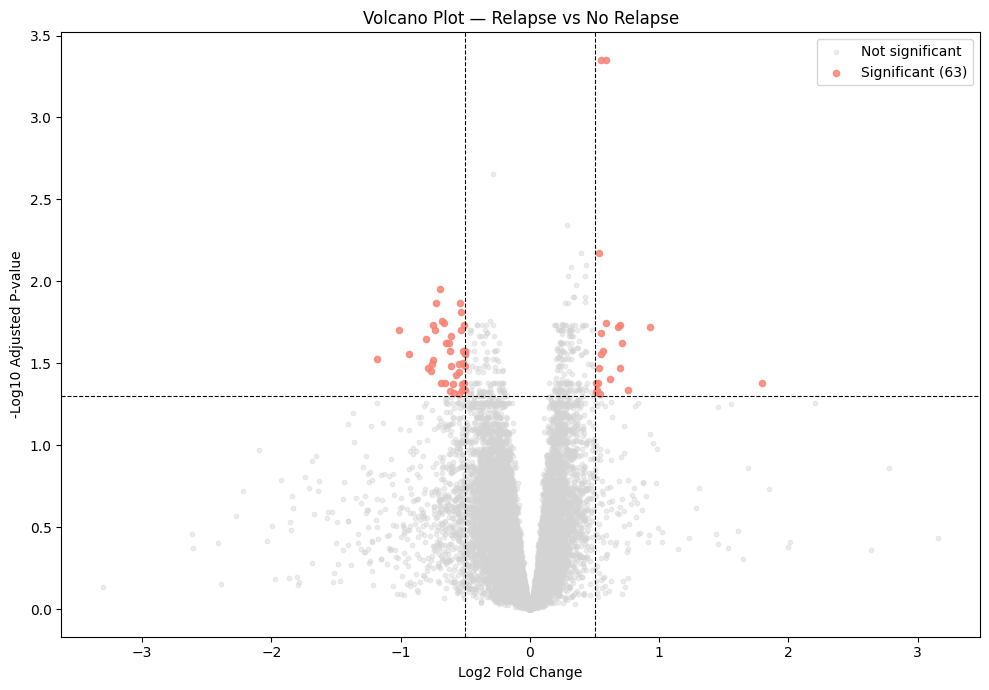

Volcano plot saved


In [12]:
# Volcano plot
plt.figure(figsize=(10, 7))

# Plot all genes
plt.scatter(results_df['log2_fold_change'], 
            -np.log10(results_df['p_adjusted']),
            alpha=0.4, color='lightgrey', s=10, label='Not significant')

# Plot significant genes
sig = results_df[results_df['significant']]
plt.scatter(sig['log2_fold_change'],
            -np.log10(sig['p_adjusted']),
            alpha=0.8, color='salmon', s=20, label=f'Significant ({len(sig)})')

# Threshold lines
plt.axhline(-np.log10(0.05), color='black', linestyle='--', linewidth=0.8)
plt.axvline(0.5, color='black', linestyle='--', linewidth=0.8)
plt.axvline(-0.5, color='black', linestyle='--', linewidth=0.8)

plt.title('Volcano Plot — Relapse vs No Relapse')
plt.xlabel('Log2 Fold Change')
plt.ylabel('-Log10 Adjusted P-value')
plt.legend()
plt.tight_layout()
plt.savefig('../data/volcano_plot.png', dpi=150)
plt.show()
print("Volcano plot saved")

Grey dots - 22,220 genes with no significant difference

Red dots - 63 genes that are significantly different between relapsed and non-relapsed patients

Right of right dashed line - upregulated in relapsed patients (more active)

Left of left dashed line - downregulated in relapsed patients (less active)

Above horizontal dashed line - statistically significant

Top right dots - most interesting genes, highly upregulated and very significant

In [13]:
#top 2 most significant upregulated genes
top_genes = results_df[results_df['log2_fold_change'] > 0].sort_values('p_adjusted').head(2)
print(top_genes[['log2_fold_change', 'p_value', 'p_adjusted']])

             log2_fold_change       p_value  p_adjusted
gene                                                   
203218_at            0.547832  3.363678e-08    0.000445
209380_s_at          0.590319  3.992553e-08    0.000445
